# Results analysis: figures and tables — YOLO26-seg vs. U-Net vs. SAM 3 (ISIC 2018 Task 1)

Master analysis notebook for the thesis. It reads **only** the Phase 5 outputs of the three 5-phase pipelines and produces the
cross-architecture tables (LaTeX + CSV), the paired statistics and the figures. **No training, no GPU, no
re-evaluation** — run it after `run_pipeline*.sh --phases 5` has finished in the three repositories and the
`logs/<pipeline>/` folders are on this machine.

| Output | Content |
|---|---|
| Table 1 | Test accuracy (DSC, JSI, ISIC JSI$_{0.65}$, Boundary IoU, NSD, HD95) with bootstrap 95 % CI |
| Table 2 | Batch-1 efficiency: params, GFLOPs, median / P95 latency, FPS, peak VRAM, real-time criterion |
| Table 3 | Effect of HPO (Optimized − Baseline, paired) for every model |
| Table 4 | FP16 vs. FP32: accuracy cost and speed-up |
| Table 5 | Training cost per phase (GPU hours) |
| Table 6 | Phase 2 cross-validation vs. test (generalisation check) |
| Table 7 | Paired cross-architecture tests on per-image DSC (all pairs, Holm-adjusted) |
| Figure 1 | Accuracy (DSC, JSI) vs. latency, FPS and parameters, with the Pareto front |
| Figure 2 | Training time and inference time (median → P95) with the real-time budget |
| Figure 3 | Per-image score distributions |
| Figure 4 | Pairwise ΔDSC matrix with Holm-adjusted significance |
| Figure 5 | Boundary metrics (Boundary IoU, NSD, HD95) with 95 % CI |
| Figure 6 | Peak VRAM (model allocator vs. whole process incl. CUDA context) |

**Where things are.** This notebook and `results_aggregator.py` live in the folder that contains the three
repositories (`sandbox_yolo26/`, `sandbox_unet/`, `sandbox_sam3/`; any letter case), or in `<repo>/analysis/`. The
pipelines are found automatically under `<repo>/logs/<PIPELINE_NAME>/`; override with `$YOLO26_PIPELINE_DIR`,
`$UNET_PIPELINE_DIR`, `$SAM3_PIPELINE_DIR`. Everything is written to `<root>/analysis_outputs/`
(`tables/*.tex|csv`, `figures/*.pdf|png`, `data/*.csv`). The same outputs can be produced headless with
`python results_aggregator.py`.

**LaTeX.** Tables use `booktabs` and `\resizebox` → `\usepackage{booktabs,graphicx}`; include with `\input{...}`.

**Requirements.** `numpy`, `pandas`, `scipy`, `matplotlib` (no deep-learning stack).

In [1]:
# ---- Configuration ----------------------------------------------------------
PIPELINE_NAME = "pipeline_final_v1"   # logs/<PIPELINE_NAME>/ in every repository
DEPLOY_VARIANT = "optimized"          # variant compared across architectures ("optimized" = Phase 4, chosen a priori)
PRECISION = "fp32"                    # primary precision (training was FP32); FP16 is in Table 4
REALTIME_FPS = 30                     # real-time criterion: end-to-end P95 latency <= 1000 / REALTIME_FPS ms
N_BOOT = 2000                         # bootstrap resamples (paired CIs), seeded
ROOT = None                           # folder holding the three repositories; None = auto-discover

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import results_aggregator as agg  # noqa: E402  (next to this notebook)

pd.set_option("display.max_columns", 40, "display.width", 200)
agg.setup_style()
PHASE5_MISSING = "⚠️ Phase 5 results not yet generated. Training is likely still in progress. Skipping cell execution."
try:
    art = agg.build(ROOT, PIPELINE_NAME, DEPLOY_VARIANT, PRECISION, REALTIME_FPS, n_boot=N_BOOT)
except FileNotFoundError as err:   # no pipeline has written its Phase 5 summary yet
    art, missing_reason = None, str(err)
PHASE5_READY = art is not None
if not PHASE5_READY:
    print(PHASE5_MISSING)
    print("[info]", missing_reason)
else:
    written = agg.write_tables(art)
    print("root     :", art.root)
    for k, p in art.pipes.items():
        print(f"pipeline : {agg.ARCH_BY_KEY[k].label:<11} {p.root}")
    print("outputs  :", art.out)
    print(f"systems  : {list(art.sel.system)}  ({DEPLOY_VARIANT}, {PRECISION})")
    print(f"tables   : {len(written)} written to {art.out / 'tables'}")
    for w in art.warnings:
        print("WARNING  :", w)

root     : /home/antoniovinicius/projects
pipeline : U-Net       /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1
outputs  : /home/antoniovinicius/projects/analysis_outputs
systems  : ['U-Net']  (optimized, fp32)
tables   : 6 written to /home/antoniovinicius/projects/analysis_outputs/tables


## Pipeline notes to disclose

Protocol deviations recorded by the pipelines themselves (`protocol_notes` and `warnings` of every
`summary/final_results.json`). Everything printed here belongs in the Methods or Limitations section.

In [2]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    for k, p in art.pipes.items():
        for n in p.report.get("protocol_notes", []):
            print(f"[{agg.ARCH_BY_KEY[k].label}] NOTE: {n}")
    contended = [s for s, c in zip(art.sel.system, art.sel.get("contended", [None] * len(art.sel))) if pd.notna(c) and bool(c)]
    print("contended benchmarks (re-run Phase 5b on an idle GPU before quoting):", contended or "none")

contended benchmarks (re-run Phase 5b on an idle GPU before quoting): ['U-Net']


## Table 1 — Test-set accuracy

Per-image mean over the 1,000 official test images with the seeded bootstrap 95 % CI written by each pipeline's
Phase 5a (identical metric code in the three repositories: `segmentation_metrics.py`). Best value per column in
bold in the LaTeX file. HD95 is in pixels at the dataset resolution (longer side ≤ 1,024 px); a missed lesion scores
the image diagonal (Metrics Reloaded: penalise, never drop).

In [3]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    display(art.tables["accuracy"])

,System,DSC,JSI,JSI$_{0.65}$,Boundary IoU,NSD,HD95 (px),Missed
0,U-Net,"0.871 [0.861, 0.880]","0.795 [0.783, 0.806]","0.723 [0.703, 0.743]","0.358 [0.344, 0.371]","0.561 [0.543, 0.580]","89.6 [82.7, 96.9]",2


## Table 2 — Efficiency at batch = 1 and the real-time criterion

Forward = network only (CUDA events); end-to-end = decoded image in host memory → binary mask at dataset resolution
in host memory (the mask that is scored), P95 over 100 distinct test images. VRAM: PyTorch allocator peak (the
model) and the driver-level process peak (CUDA context and allocator cache included — what a device must provide).
GFLOPs at each model's native input: YOLO26 640 px, U-Net 256 px, SAM 3 1008 px (thop for the CNNs,
`FlopCounterMode` for SAM 3, which counts the attention products thop cannot see).

In [4]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    display(art.tables["efficiency"])

,System,Params (M),GFLOPs,Input (px),Fwd median (ms),Fwd P95 (ms),FPS (fwd),E2E median (ms),E2E P95 (ms),FPS (E2E),VRAM alloc. (MB),VRAM process (MB),Real-time (30 FPS)
0,U-Net,2.2,6.4,256,1.59,1.68,626.8,4.84,5.57,205.6,35,424,yes


## Figure 1 — Accuracy vs. efficiency

The central figure of the "lightweight vs. foundation model" argument: test DSC and JSI (95 % CI) against the measured
latency, throughput and parameter count. One colour per architecture; YOLO26 sizes are joined n → x; the dotted line
is the Pareto front (no other model is both faster/smaller and more accurate).

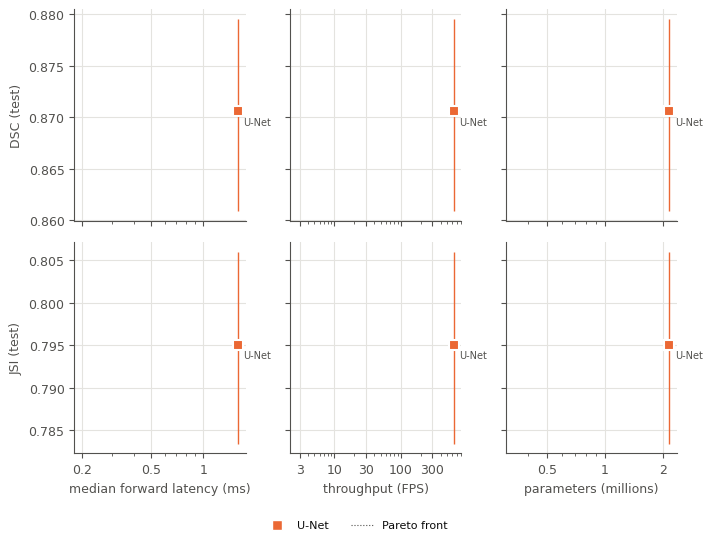

,system,arch_label,dsc_mean,dsc_ci95_low,dsc_ci95_high,jsi_mean,jsi_ci95_low,jsi_ci95_high,jsi_thr_mean,jsi_thr_ci95_low,jsi_thr_ci95_high,biou_mean,biou_ci95_low,biou_ci95_high,nsd_mean,nsd_ci95_low,nsd_ci95_high,hd95_mean,hd95_ci95_low,hd95_ci95_high,n_images,n_empty_pred,params_M,gflops,input_px,fwd_median_ms,fwd_p95_ms,fwd_fps,e2e_median_ms,e2e_p95_rt_ms,e2e_fps,vram_peak_allocated_mb,vram_process_peak_mb,realtime_30fps
0,U-Net,U-Net,0.8706,0.8609,0.8796,0.7951,0.7834,0.806,0.7234,0.7029,0.7431,0.3581,0.3445,0.3713,0.5614,0.5427,0.5799,89.5788,82.6953,96.8813,1000,2,2.1587,6.4005,256,1.5862,1.6809,626.8173,4.8422,5.5694,205.6215,34.9067,424.0,True


In [5]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    fig = agg.fig_accuracy_vs_efficiency(art.sel, metrics=("dsc", "jsi"), save=art.save_fig)
    plt.show()
    display(art.tables["accuracy_numeric"].merge(art.tables["efficiency_numeric"], on=["system", "arch_label"]).round(4))

## Figure 2 — Training and inference time

(a) GPU hours of the whole 5-phase protocol (Phases 1–4) and of the final model alone (Phase 4). (b) Median batch-1
latency with a line to its P95, forward vs. end-to-end and FP32 vs. FP16, against the real-time budget.

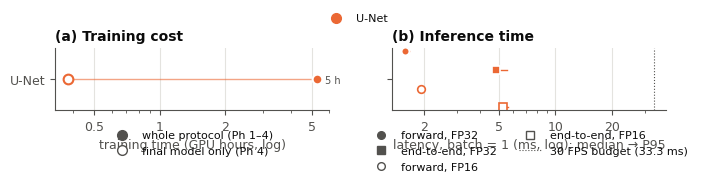

,System,arch,Ph 1 baseline (h),Ph 2 CV (5 folds) (h),Ph 3 HPO (h),Ph 4 optimized (h),Total (h),Epochs (Ph 1),s / epoch (Ph 1)
0,U-Net,unet,0.38,1.7,2.83,0.38,5.29,120,11.34


In [6]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    fig = agg.fig_training_inference_time(art.sel, art.tables["training"], REALTIME_FPS, save=art.save_fig)
    plt.show()
    display(art.tables["training"].round(2))

## Figure 3 — Per-image distributions

Box = IQR, centre line = median, whiskers = P5–P95, ◆ = mean. The mean (the reported figure) and the tails
(failures) can tell different stories — read with Table 1's "Missed" column.

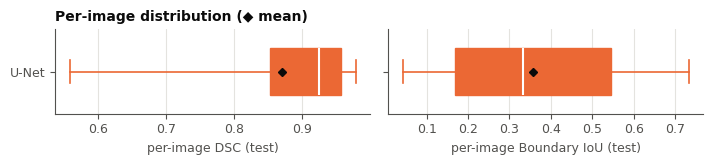

In [7]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    fig = agg.fig_per_image_distributions(art.sel, art.per_image, save=art.save_fig)
    plt.show()

## Paired statistics across architectures

All systems are scored on the **same** 1,000 test images, so comparisons are paired by ISIC ID. Omnibus: Friedman
test per metric (Kendall's W = effect size; mean rank 1 = best). Pairs: mean difference with a seeded paired
bootstrap 95 % CI, two-sided Wilcoxon signed-rank test, matched-pairs rank-biserial r, and Holm-adjusted p-values
within each metric (all pairs = one family). Report the CI of the difference, not only the p-value: with
n = 1,000, clinically negligible differences can be "significant".

In [8]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    display(art.friedman.round(4))

""


In [9]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
elif art.tests.empty:
    print("⚠️ Paired cross-architecture tests need Phase 5 results from at least two architectures. Skipping cell execution.")
else:
    display(agg.pairwise_table(art.tests, "dsc"))

⚠️ Paired cross-architecture tests need Phase 5 results from at least two architectures. Skipping cell execution.


## Figure 4 — Pairwise ΔDSC matrix

In [10]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
elif art.tests.empty:
    print("⚠️ Paired cross-architecture tests need Phase 5 results from at least two architectures. Skipping cell execution.")
else:
    systems = [s for s in art.sel.system if s in art.per_image]
    fig = agg.fig_pairwise_matrix(art.tests, systems, "dsc", save=art.save_fig)
    plt.show()
    for m in ("jsi", "biou", "hd95"):   # the other metrics: same layout, saved for the supplementary material
        plt.close(agg.fig_pairwise_matrix(art.tests, systems, m, save=art.save_fig))

⚠️ Paired cross-architecture tests need Phase 5 results from at least two architectures. Skipping cell execution.


## Figure 5 — Boundary metrics (Metrics Reloaded)

Boundary IoU (band = 2 % of the image diagonal), NSD (tolerance = 1 % of the diagonal) and HD95, per-image mean with
bootstrap 95 % CI. Overlap scores are dominated by the lesion interior; these measure contour adherence.

In [11]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
elif art.tests.empty:
    print("⚠️ Paired cross-architecture tests need Phase 5 results from at least two architectures. Skipping cell execution.")
else:
    fig = agg.fig_boundary_metrics(art.sel, save=art.save_fig)
    plt.show()
    display(art.tests[art.tests.metric.isin(["biou", "nsd", "hd95"])][["metric", "A", "B", "delta", "ci95_low", "ci95_high", "p_holm"]].round(4))

⚠️ Paired cross-architecture tests need Phase 5 results from at least two architectures. Skipping cell execution.


## Figure 6 — Peak GPU memory

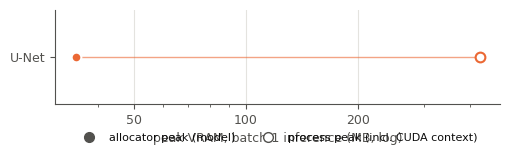

In [12]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    fig = agg.fig_memory(art.sel, save=art.save_fig)
    plt.show()

## Table 3 — Effect of HPO (Optimized − Baseline)

In [13]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    display(art.tables["hpo_gain"])

,System,n,ΔDSC,p (DSC),ΔJSI,p (JSI),ΔBoundary IoU,p (Boundary IoU),ΔNSD,p (NSD),ΔHD95 (px),p (HD95 (px))
0,U-Net,1000,"0.0014 [-0.0057, 0.0091]",0.007,"-0.0023 [-0.0097, 0.0060]",0.004,"-0.0195 [-0.0274, -0.0121]",<0.001,"-0.0291 [-0.0401, -0.0181]",<0.001,"7.0 [1.4, 12.5]",<0.001


## Table 4 — FP16 vs. FP32

In [14]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    display(art.tables["precision"].round(4))

,System,DSC FP32,DSC FP16,ΔDSC (FP16−FP32),Fwd FP32 (ms),Fwd FP16 (ms),Speed-up (fwd),E2E FP32 (ms),E2E FP16 (ms),Speed-up (E2E),VRAM FP32 (MB),VRAM FP16 (MB)
0,U-Net,0.8706,0.8707,0.0001,1.5862,1.9333,0.8204,4.8422,5.2808,0.9169,34.9067,21.272


## Table 6 — Cross-validation vs. test

In [15]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    display(art.tables["cv_vs_test"])

,System,CV DSC (mean ± SD),CV JSI (mean ± SD),"Test DSC, Baseline","Test JSI, Baseline"
0,U-Net,0.883 ± 0.007,0.811 ± 0.009,"0.869 [0.859, 0.879]","0.797 [0.785, 0.809]"


## Key numbers for the Results section

Generated from the tables above — copy, then rephrase. Every number is traceable to `analysis_outputs/`.

In [16]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    for line in agg.key_numbers(art):
        print("•", line)
    print("\nFiles:")
    for f in sorted((art.out / "tables").glob("*.tex")) + sorted((art.out / "figures").glob("*.pdf")):
        print("  ", f.relative_to(art.out))

• Highest test DSC: U-Net with 0.871 [0.861, 0.880] (JSI 0.795 [0.783, 0.806]).
• Fastest network: U-Net, forward median 1.59 ms (P95 1.68 ms, 627 FPS), end-to-end median 4.84 ms (P95 5.57 ms).
• Meeting the 30-FPS real-time criterion (E2E P95 ≤ 33.3 ms, FP32): U-Net.

Files:
   tables/table1_accuracy.tex
   tables/table2_efficiency.tex
   tables/table3_hpo_gain.tex
   tables/table4_fp16.tex
   tables/table5_training_cost.tex
   tables/table6_cv_vs_test.tex
   figures/fig1_accuracy_vs_efficiency.pdf
   figures/fig2_training_inference_time.pdf
   figures/fig3_per_image_distributions.pdf
   figures/fig6_memory.pdf


## Reading notes (keep these caveats in the thesis)

* **Resolution.** Every model is scored at the dataset resolution against the same official masks, but each runs at
  its own native input (U-Net 256, YOLO26 640, SAM 3 1008 px). Part of the accuracy and cost differences is the input
  resolution — state it.
* **GFLOPs** are reported at the native input; the U-Net's GFLOPs at 640 px are in `data/systems_selected.csv`
  (`gflops_640`) for a resolution-matched comparison. thop (CNNs) and `FlopCounterMode` (SAM 3) agree on convolutions
  and linear layers; only the latter counts attention products.
* **Budgets.** YOLO26 and U-Net: 120 epochs, HPO 30 × 30; SAM 3: 30 epochs, HPO 10 × 10 (compute). None uses early
  stopping. See `methodology_notes.md`.
* **Latency** depends on the GPU, driver and software stack (recorded in each efficiency JSON); quote the GPU model
  with every number, and never the per-image `infer_ms` column of Phase 5a (a by-product, not a benchmark).
* **Variant.** The comparison uses the variant fixed in advance (`DEPLOY_VARIANT`); Table 3 shows whether HPO helped.